# Machine Learning

In [1]:
# Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load pre install dataaaset
data = sns.load_dataset('mpg')
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [3]:
# for model tarining and test we take only numeric value
# for 'data' set -- output parameter ('mpg'), input parameter (all excluding 'mpg','origin','name' )
data.drop(['origin','name'], axis=1, inplace=True)

In [4]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


<Axes: >

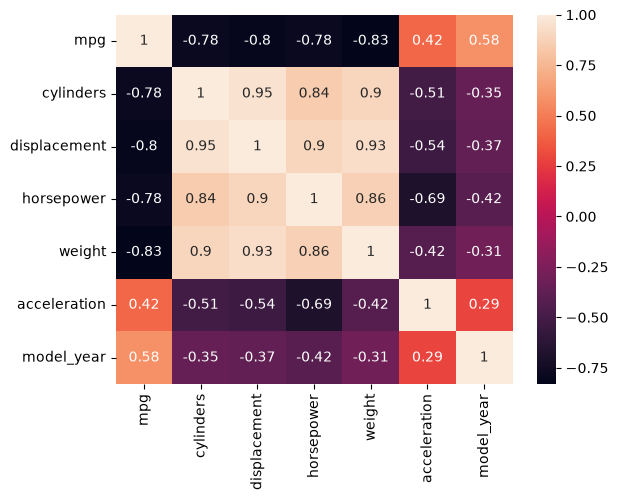

In [5]:
sns.heatmap(data.corr(), annot=True)

In [6]:
# check if any null vlaues
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
dtype: int64

In [7]:
# drop all null values
data = data.dropna()

In [8]:
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
dtype: int64

In [9]:
# Get Input and target
X = data.drop('mpg', axis=1)
X.head(2)

,cylinders,displacement,horsepower,weight,acceleration,model_year
0,8,307.0,130.0,3504,12.0,70
1,8,350.0,165.0,3693,11.5,70


In [10]:
y = data['mpg']
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

In [13]:
# create train and test data
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [15]:
# since , we got train and test dataset for ML now train the model
# we have algorithms --- Linear Regression , Decision Tree, Random forest, knn
# we use DecisionTree Regressor for the given dataset, since 'mpg' is a continuous value
from sklearn.tree import DecisionTreeRegressor

In [16]:
# create a model of decisontreeregressor
dt = DecisionTreeRegressor()

In [17]:
dt

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [18]:
# train the model
dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [19]:
# predict the value and check accuracy
dt.predict(X_test)

array([25. , 20. , 39. , 33. , 27. , 27. , 12. , 31.5, 18. , 31. , 15. ,
       19. , 15.5, 27. , 16.5, 27. , 18. , 32.4, 31.3, 34. , 23. , 36. ,
       35.1, 18. , 31. , 28. , 19. , 18. , 26. , 25. , 16. , 20.6, 23.9,
       28. , 14. , 31. ,  9. , 25. , 14. , 12. , 14. , 28. , 36. , 26. ,
       16. , 11. , 19. , 46.6, 25. , 33. , 14. , 21. , 21. , 34. , 38. ,
       16. , 19. , 19. , 24. , 23. , 11. , 22. , 28.4, 22. , 24. , 26. ,
       24.5, 33. , 23.9, 14. , 25. , 13. , 23.8, 19. , 20.2, 24. , 13. ,
       18. , 24. ])

In [20]:
y_pred = dt.predict(X_test)
y_pred

array([25. , 20. , 39. , 33. , 27. , 27. , 12. , 31.5, 18. , 31. , 15. ,
       19. , 15.5, 27. , 16.5, 27. , 18. , 32.4, 31.3, 34. , 23. , 36. ,
       35.1, 18. , 31. , 28. , 19. , 18. , 26. , 25. , 16. , 20.6, 23.9,
       28. , 14. , 31. ,  9. , 25. , 14. , 12. , 14. , 28. , 36. , 26. ,
       16. , 11. , 19. , 46.6, 25. , 33. , 14. , 21. , 21. , 34. , 38. ,
       16. , 19. , 19. , 24. , 23. , 11. , 22. , 28.4, 22. , 24. , 26. ,
       24.5, 33. , 23.9, 14. , 25. , 13. , 23.8, 19. , 20.2, 24. , 13. ,
       18. , 24. ])

In [21]:
# since, all true value from X_test are in y_test and all predicted value of X_test are in y_pred, its time to compare values in y_test and y_pred to check the accuracy of model

In [24]:
# import Metrics for Regression from sklearn, mean squared error, mean absolute error, r2 score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [25]:
ms = mean_squared_error(y_pred,y_test)
ma = mean_absolute_error(y_pred,y_test)
rs = r2_score(y_pred,y_test)

In [26]:
#print the metrics of DT
print("Model Name: DecisionTreeRegressor")
print(f"Mean squred error: {ms}")
print(f"Mean absolute error: {ma}")
print(f"R2 score: {rs}")

Model Name: DecisionTreeRegressor
Mean squred error: 11.696708860759493
Mean absolute error: 2.29620253164557
R2 score: 0.7988714187266419


In [27]:
# R2 score: [0 - 1] range
# R2 score: 80% which is moderate accuracy, 

In [28]:
# mean square error
# mean absolute error
# R square error
# labelled data and unlabeled data
# train and test  data

In [29]:
# save the model
import joblib

In [30]:
# dump: save the model
# load : loads the model

In [31]:
joblib.dump(dt,'decision_tree_model.dt')

['decision_tree_model.dt']

In [32]:
# this save model can be used in other system to predict 'mpg'

In [33]:
# Simple Linear Regression : one input, one output
# Multiple Linear Regression: two or more input, one output

In [34]:
data.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70


In [35]:
# Simple Linear Regression
df = data[['mpg','horsepower']]
df

,mpg,horsepower
0,18.0,130.0
1,15.0,165.0
2,18.0,150.0
3,16.0,150.0
4,17.0,140.0
...,...,...
393,27.0,86.0
394,44.0,52.0
395,32.0,84.0
396,28.0,79.0


<Axes: xlabel='mpg', ylabel='horsepower'>

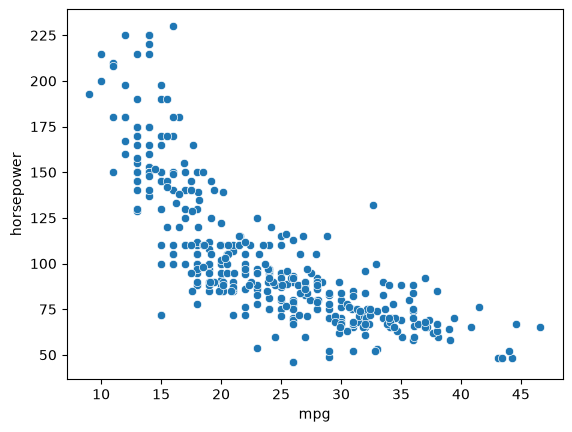

In [36]:
sns.scatterplot(x='mpg',y='horsepower', data=df)

In [43]:
# Create X (input) , y (output) parameter
X = data[['horsepower']]
X

,horsepower
0,130.0
1,165.0
2,150.0
3,150.0
4,140.0
...,...
393,86.0
394,52.0
395,84.0
396,79.0


In [38]:
y = data['mpg']
y

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 392, dtype: float64

In [44]:
# create train and test data
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [45]:
# create a model
from sklearn.linear_model import LinearRegression

In [46]:
lr = LinearRegression()

In [47]:
# train the model 'lr'
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.16]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['horsepower']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,40.61
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [48]:
# predit the vlaue using X_test
y_pred = lr.predict(X_test)
y_pred

array([29.38688782, 21.90741463, 30.85026301, 29.22429057, 26.62273468,
       28.41130436, 12.96456625, 28.41130436, 25.15935949, 32.63883268,
        9.71262139, 23.04559533, 15.4035249 , 28.41130436, 18.98066425,
       26.2975402 , 25.15935949, 28.41130436, 27.59831814, 26.2975402 ,
       25.15935949, 32.15104095, 29.54948506, 19.46845598, 29.7120823 ,
       25.97234571, 26.46013744, 23.53338706, 33.12662441, 28.24870711,
       17.02949733, 25.97234571, 20.2814422 , 28.5739016 , 16.21651112,
       29.7120823 , 17.84248355, 27.59831814, 17.84248355,  5.64769031,
       19.46845598, 28.41130436, 28.5739016 , 27.92351263, 16.5417056 ,
        5.64769031, 24.34637328, 29.38688782, 28.89909609, 29.22429057,
       15.72871939, 25.15935949, 25.97234571, 26.2975402 , 22.39520636,
       22.72040084, 22.72040084, 24.34637328, 25.15935949, 25.15935949,
        4.02171787, 25.97234571, 21.90741463, 26.2975402 , 25.15935949,
       27.4357209 , 26.2975402 , 29.22429057, 22.72040084,  8.41

In [49]:
# compare y_pred with the y_test
ms = mean_squared_error(y_pred,y_test)
ma = mean_absolute_error(y_pred,y_test)
rs = r2_score(y_pred,y_test)

In [50]:
ms

22.153237123863413

In [51]:
ma

3.782512710126959

In [52]:
rs

0.4573574057780647

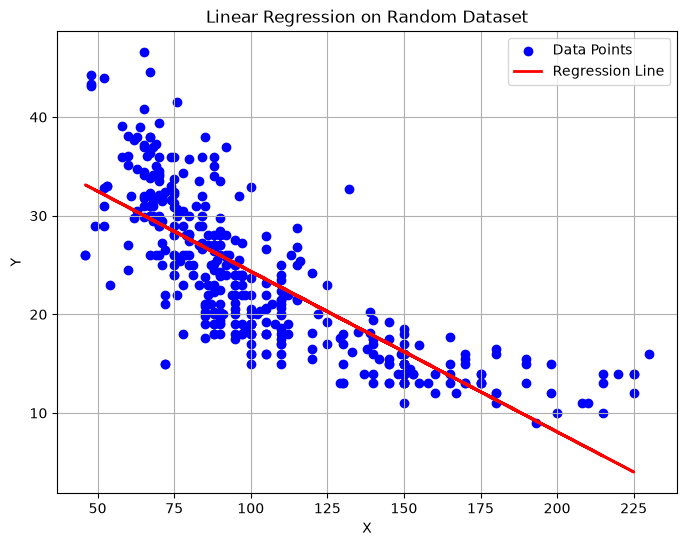

In [53]:
plt.figure(figsize=(8,6)) 
plt.scatter(X, y, color='blue', label='Data Points') 
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line') 
plt.title('Linear Regression on Random Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

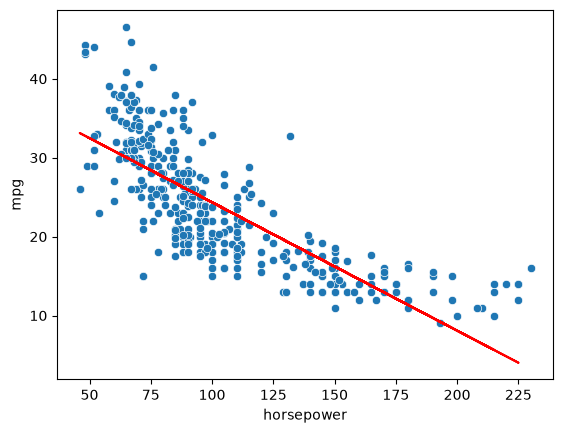

In [59]:
# original 'df' dataset
sns.scatterplot(x='horsepower',y='mpg', data=df)
plt.plot(X_test,y_pred, color='red')

In [60]:
# practice : load 'tips' dataset
# do encoding: 'sex', 'smoker', 'day','time' ---do manual encoding
# y is tips, X al other than 'tip'
# using 'DT', create a model to predict 'tip' and check accuracy

# Regression Analysis

In [3]:
#load dataset
data = sns.load_dataset('tips')
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# check any null 
data.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
# perform encoding on 'categorial vales' e.g 'sex','smoker','day','time' do manual encoding


In [7]:
# ecoding 'sex' value
data['sex'].unique()

['Female', 'Male']
Categories (2, str): ['Male', 'Female']

In [10]:
enc_sex = {'Female':1,'Male':0}
data['sex']=data.sex.map(enc_sex)

In [11]:
data.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,1,No,Sun,Dinner,2
1,10.34,1.66,0,No,Sun,Dinner,3


In [12]:
# smoker
data['smoker'].unique()

['No', 'Yes']
Categories (2, str): ['Yes', 'No']

In [15]:
enc_smoker = {'No':0,'Yes':1}
data['smoker'] = data.smoker.map(enc_smoker)

In [16]:
data.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,1,0,Sun,Dinner,2
1,10.34,1.66,0,0,Sun,Dinner,3


In [18]:
# day
data.day.unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']

In [20]:
enc_day = {'Sun':1,'Thur':2,'Fri':3,'Sat':4}
data['day']=data['day'].map(enc_day)

In [21]:
data.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,1,0,1,Dinner,2
1,10.34,1.66,0,0,1,Dinner,3


In [22]:
# time
data.time.unique()

['Dinner', 'Lunch']
Categories (2, str): ['Lunch', 'Dinner']

In [23]:
enc_time = {'Dinner':1,'Lunch':2}
data['time']=data.time.map(enc_time)

In [24]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,1,0,1,1,2
1,10.34,1.66,0,0,1,1,3
2,21.01,3.50,0,0,1,1,3
3,23.68,3.31,0,0,1,1,2
4,24.59,3.61,1,0,1,1,4


In [26]:
# from the dataset, y=tip, X=all except tip
X = data.drop('tip', axis=1,)
X

,total_bill,sex,smoker,day,time,size
0,16.99,1,0,1,1,2
1,10.34,0,0,1,1,3
2,21.01,0,0,1,1,3
3,23.68,0,0,1,1,2
4,24.59,1,0,1,1,4
...,...,...,...,...,...,...
239,29.03,0,0,4,1,3
240,27.18,1,1,4,1,2
241,22.67,0,1,4,1,2
242,17.82,0,0,4,1,2


In [27]:
y = data.tip
y

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

In [28]:
# split the data into train and test
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [30]:
from sklearn.tree import DecisionTreeRegressor

In [33]:
dt = DecisionTreeRegressor()
dt

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [34]:
# train the model 'dt'
dt.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [35]:
# predit value with X_test
y_pred = dt.predict(X_test)
y_pred

array([2.01, 1.32, 3.5 , 2.  , 2.  , 3.  , 5.  , 1.8 , 2.5 , 3.  , 3.  ,
       1.98, 2.  , 2.5 , 1.25, 2.83, 3.76, 3.  , 2.  , 6.  , 3.61, 4.06,
       2.5 , 1.25, 3.5 , 3.39, 2.6 , 4.29, 1.01, 6.73, 4.67, 1.  , 1.75,
       4.19, 1.01, 3.61, 2.2 , 4.73, 2.  , 3.6 , 1.98, 2.5 , 3.31, 1.66,
       1.98, 1.  , 2.  , 3.  , 2.  ])

In [37]:
# check the y_pred and y_test value using metrices
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 

In [39]:
ms = mean_squared_error(y_pred,y_test)
ma = mean_absolute_error(y_pred,y_test)
rs = r2_score(y_pred,y_test)

In [40]:
print("DecissionTreeRegressor model")
print('Mean_squared_error:',ms)
print('Mean absolute error: ',ma)
print('R2 score: ',rs)

DecissionTreeRegressor model
Mean_squared_error: 1.074383673469388
Mean absolute error:  0.8040816326530613
R2 score:  0.3358199194248883


In [41]:
# r2 sorce : 33% only which is less accurate

<Axes: xlabel='total_bill', ylabel='tip'>

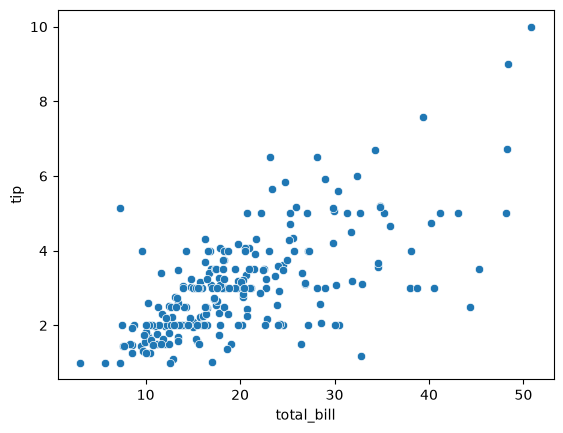

In [42]:
sns.scatterplot(x='total_bill',y='tip', data=data)

<Axes: >

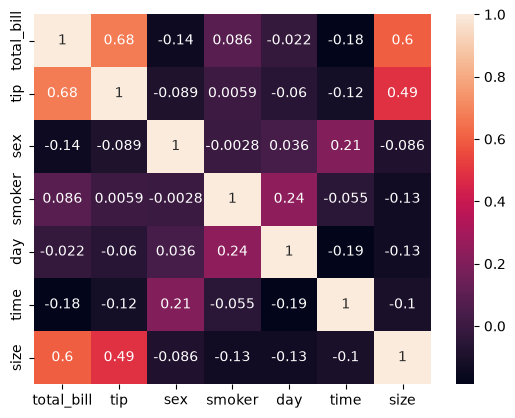

In [43]:
sns.heatmap(data.corr(), annot=True)